<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-2/City%20AQI%20and%20Crop%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

city = pd.read_csv('/content/drive/MyDrive/ML Datasets/Lab 1/city_day.csv')
crop = pd.read_csv('/content/drive/MyDrive/ML Datasets/Lab 1/crop_production.csv')



city.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [2]:
crop.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [3]:
print("City:")
print(city.shape)
print("\n\n")
print("Crop:")
print(crop.shape)
print("\n\n\n")
print("\n\n\n")
print(city.info())
print("\n\n")
print(crop.info())

City:
(29531, 16)



Crop:
(246091, 7)








<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None



<class 'pandas.core.frame.DataFrame'>
RangeIn

In [4]:
print("City:")
print(city.describe())
print("\n\n\n")
print("Crop:")
print(crop.describe())

City:
              PM2.5          PM10            NO           NO2           NOx  \
count  24933.000000  18391.000000  25949.000000  25946.000000  25346.000000   
mean      67.450578    118.127103     17.574730     28.560659     32.309123   
std       64.661449     90.605110     22.785846     24.474746     31.646011   
min        0.040000      0.010000      0.020000      0.010000      0.000000   
25%       28.820000     56.255000      5.630000     11.750000     12.820000   
50%       48.570000     95.680000      9.890000     21.690000     23.520000   
75%       80.590000    149.745000     19.950000     37.620000     40.127500   
max      949.990000   1000.000000    390.680000    362.210000    467.630000   

                NH3            CO           SO2            O3       Benzene  \
count  19203.000000  27472.000000  25677.000000  25509.000000  23908.000000   
mean      23.483476      2.248598     14.531977     34.491430      3.280840   
std       25.684275      6.962884     18.1337

In [5]:
print("City:")
print(city.isnull().sum())
print("\n\n\n")
print("Crop:")
print(crop.isnull().sum())

City:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64




Crop:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


# Task 1
###City Air Quality Dataset

### Observations & Context Description

Contains daily air quality measurements from 26 Indian cities between 2015–2020, including pollutant concentrations, AQI values, and air quality categories. Approximately 29,500 records and 16 attributes.

### Concerns

* Several pollutant variables have substantial missing data.
* Missing values are unevenly distributed across cities.
* Monitoring methods and reasons for missing observations are not documented.

---

### Crop Production Dataset

### Observations & Context Description

Contains crop production records across Indian states and districts from 1997–2015, including crop type, season, cultivated area, and production output. Approximately 246,000 records and 7 attributes.

### Concerns

* Missing production values in some records.
* Extremely large variation in production values may indicate outliers.
* Measurement units and data collection methodology are not documented.




# Task 2

### Handling Missing Values

**Crop Production Dataset**

Rows that had null `Production` values were dropped as they constituted only 1.5% of rows. To keep the data reliable (without altering source data) will allow us to proceed without any concerns of artificial patterns.

**Air Quality Dataset**

**Xylene** column was dropped as ~60% of its rows were null. Imputing such a large amount of data would result in more noise or artificial patterns than quality data.

**Median imputation** was used for pollutant measurements because pollution data often contains spikes caused by unusual environmental events. Using the median preserves the typical value of the variable without being distorted by extreme readings.

**Mode imputation** was used for categorical variables such as *AQI_Bucket* because the mode represents the most frequently occurring category and allows missing categorical values to be filled without introducing new categories or altering the data structure.

In summary:
* **Date** has been converted to Datetime format for future use
* **Production** and **Xylene** were dropped
* **Median → Numerical data with skewed distributions or outliers**
* **Mode → Categorical data where the most common category is the safest replacement**


In [6]:
city_cleaned = city.copy()
crop_cleaned = crop.copy()

# Convert 'Date' to datetime in the 'city_cleaned' DataFrame
city_cleaned['Date'] = pd.to_datetime(city_cleaned['Date'])

# Impute numerical columns in 'city_cleaned' DataFrame with mean grouped by 'city_cleaned'
for col in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene',  'AQI']:
    if col in city_cleaned.columns:
        city_cleaned[col] = city_cleaned.groupby('City')[col].transform(lambda x: x.fillna(x.mean()))

# Impute 'AQI_Bucket' with mode grouped by 'city_cleaned'
city_cleaned['AQI_Bucket'] = city_cleaned.groupby('City')['AQI_Bucket'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

# For any remaining NaNs in 'AQI_Bucket' (e.g., if a city_cleaned has all NaNs for AQI_Bucket), fill with 'Unknown'
city_cleaned['AQI_Bucket'] = city_cleaned['AQI_Bucket'].fillna('Unknown')

#For the columns in the `city_cleaned` DataFrame that still have missing values after group-wise imputation, fill them with the overall column mean.
# Impute remaining numerical columns in 'city_cleaned' DataFrame with overall column mean
for col in ['PM10', 'NOx', 'NH3', 'O3', 'Benzene', 'Toluene']:
    if col in city_cleaned.columns:
        city_cleaned[col] = city_cleaned[col].fillna(city_cleaned[col].mean())



crop_cleaned = crop_cleaned.dropna(subset=['Production'])
city_cleaned = city_cleaned.drop('Xylene', axis=1)


### Missing Values After Imputation

Let's check the null counts again to see the effect of the imputation.

In [7]:
print("city_cleaned after imputation:")
print(city_cleaned.isnull().sum())
print("\n\n\n")
print("crop_cleaned after imputation:")
print(crop_cleaned.isnull().sum())

city_cleaned after imputation:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64




crop_cleaned after imputation:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


# Task 3

Checking discrepancies in City and State names

In [8]:
print(city_cleaned['City'].unique())


['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


In [9]:

crop_cleaned['State_Name'].unique()

array(['Andaman and Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat',
       'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand',
       'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal'],
      dtype=object)

In [10]:
city_cleaned['City'] = city_cleaned['City'].astype(str).str.strip()
crop_cleaned['State_Name'] = crop_cleaned['State_Name'].astype(str).str.strip()
#Trims all empty spaces

Checking for duplicates

In [11]:
print("City:")
citycount = city_cleaned.shape
print(citycount)
print("\n")
print("Crop:")
print(crop_cleaned.shape)

City:
(29531, 15)


Crop:
(242361, 7)


In [12]:
print("Duplicate count for crops", crop_cleaned.duplicated().sum())
print("Duplicate count for city", city_cleaned.duplicated().sum())


Duplicate count for crops 0
Duplicate count for city 0


No duplicates found.


# Task 4

Visualizing AQI data distribution

AQI bucket mapping:


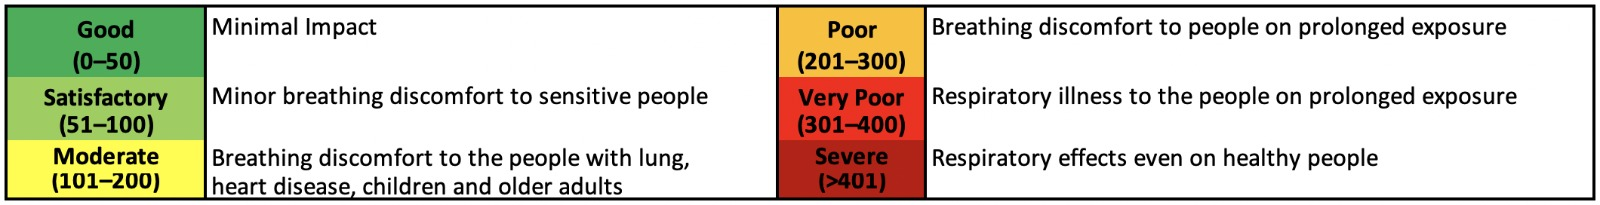

AQI bucket map provided by original data source : https://www.kaggle.com/code/rohanrao/calculating-aqi-air-quality-index-tutorial?scriptVersionId=41199538&cellId=22

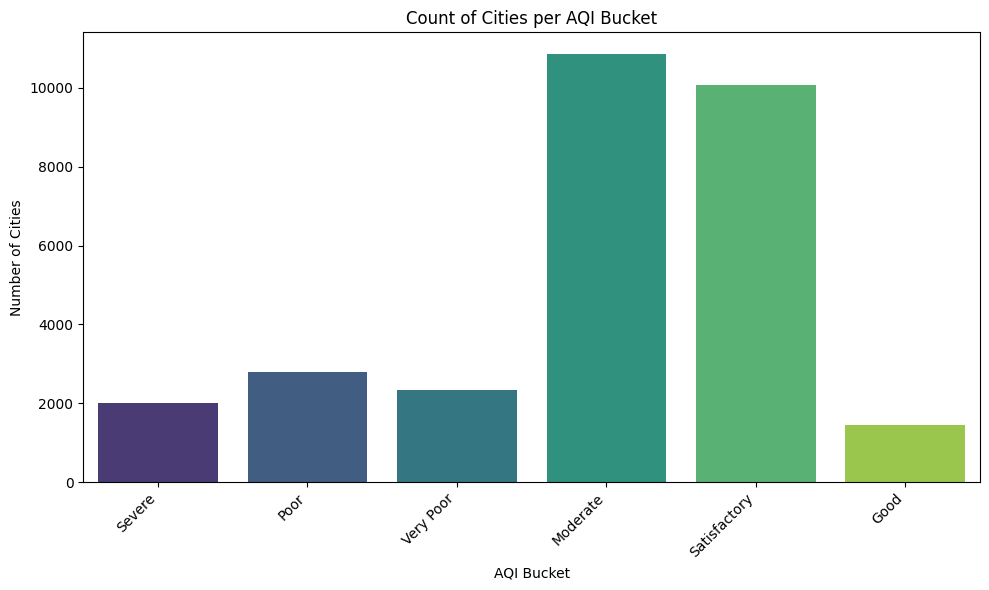

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

aqi_bucket_counts = city_cleaned['AQI_Bucket'].value_counts()

# Define the desired order for AQI Buckets
AQIbuck = city_cleaned['AQI_Bucket'].unique()
# Reindex aqi_bucket_counts according to AQIbuck to ensure desired order
aqi_bucket_counts = aqi_bucket_counts.reindex(AQIbuck)

plt.figure(figsize=(10, 6))
sns.barplot(x=aqi_bucket_counts.index, y=aqi_bucket_counts.values, palette='viridis', hue=aqi_bucket_counts.index, legend=False)
plt.title('Count of Cities per AQI Bucket')
plt.xlabel('AQI Bucket')
plt.ylabel('Number of Cities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Visualizing distribution using histplot:

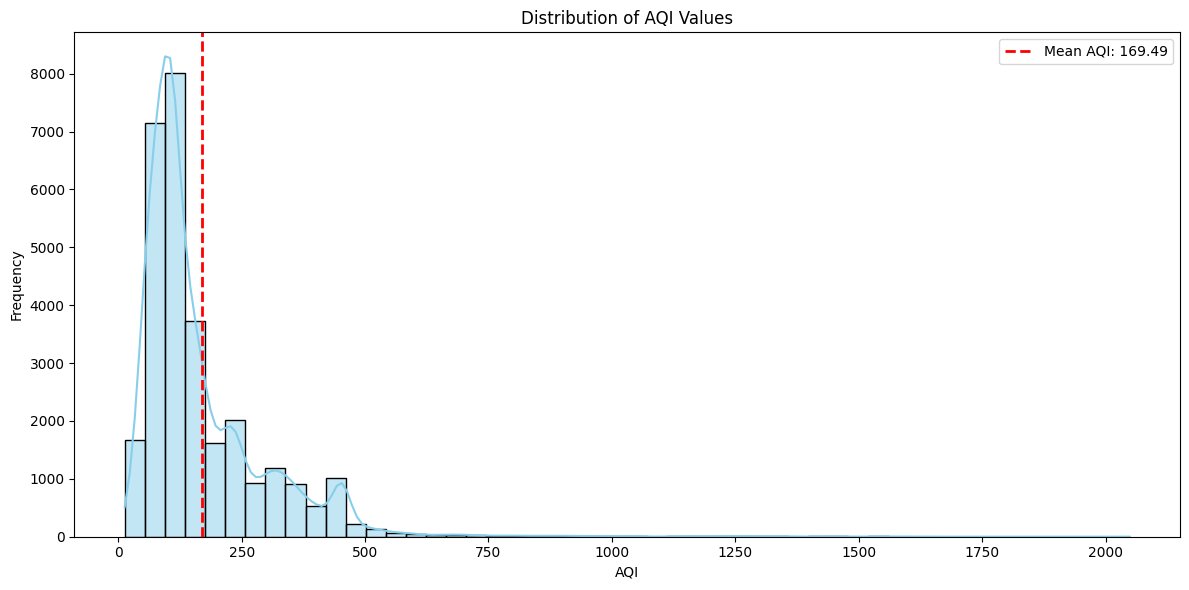

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(city_cleaned['AQI'], bins=50, kde=True, color='skyblue')

# Calculate the mean AQI
mean_aqi = city_cleaned['AQI'].mean()

# Add a vertical line for the mean
plt.axvline(mean_aqi, color='red', linestyle='dashed', linewidth=2, label=f'Mean AQI: {mean_aqi:.2f}')

plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Checking outlier profile:


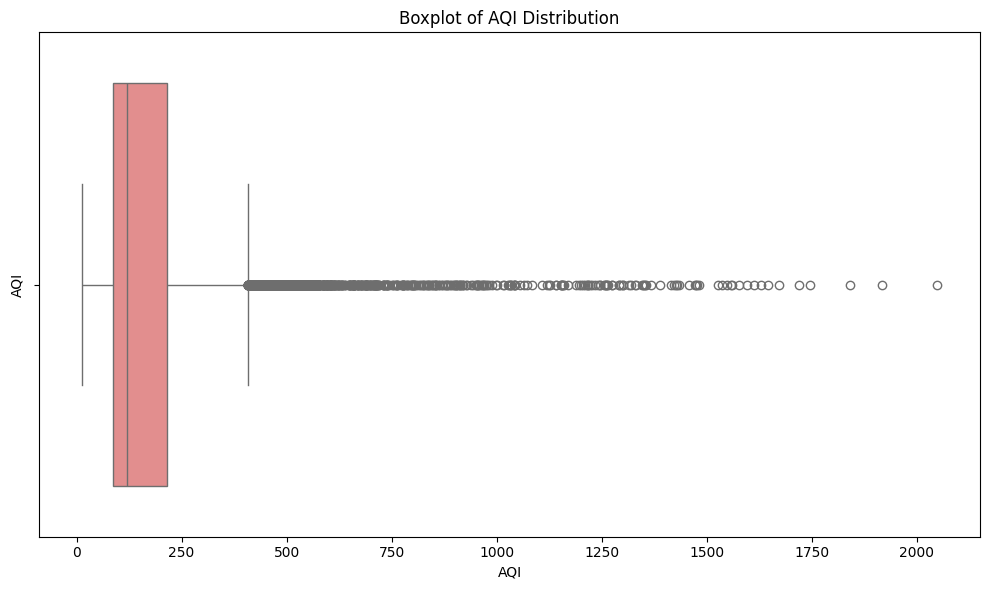

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=city_cleaned['AQI'], color='lightcoral')
plt.title('Boxplot of AQI Distribution')
plt.ylabel('AQI')
plt.tight_layout()
plt.show()

These charts show us the distribution of AQI data. As the histplot depicts, the data is highly skewed and presents a dense and positive skewed data.

Outliers:
The data although dense presents with a large amount of outliers which indicate that there are several scenarios where the AQI is significantly impacted due to some reason.

# Task 5

Based on AQI map guide given we understand that AQI values can go upto and beyond 400. The maximum recorded AQI value in India was around 700 to 800.


We will take 1000 as the threshold value to eliminate extreme values.

In [16]:
AQImax = city['AQI'].max()
print("Max AQI before eliminating:", AQImax)

print("Count before eliminating:", citycount[0])


Max AQI before eliminating: 2049.0
Count before eliminating: 29531


As we can see the data has extremely inflated values that will disrupt the distribution of data significantly.


In [17]:
city_cleaned = city_cleaned[city_cleaned['AQI'] <= 1000]

In [18]:

print("Max AQI aftr eliminating:", city_cleaned['AQI'].max())

print("Count aftr eliminating:", city_cleaned.shape[0])

Max AQI aftr eliminating: 998.0
Count aftr eliminating: 29438


# Task 6

Visualizing AQI in India over time:

The date format has already been converted to Datetime format in initial preprocessing of data


Line charts are best suited for visualizing time-series data.
Although, there are a couple of ways to approach it

Line Chart (Traditional):

As we can see, the trends of AQI across multiple cities are represented as lines over time.

We can also notice that many cities data prior to 2017 does not exist.

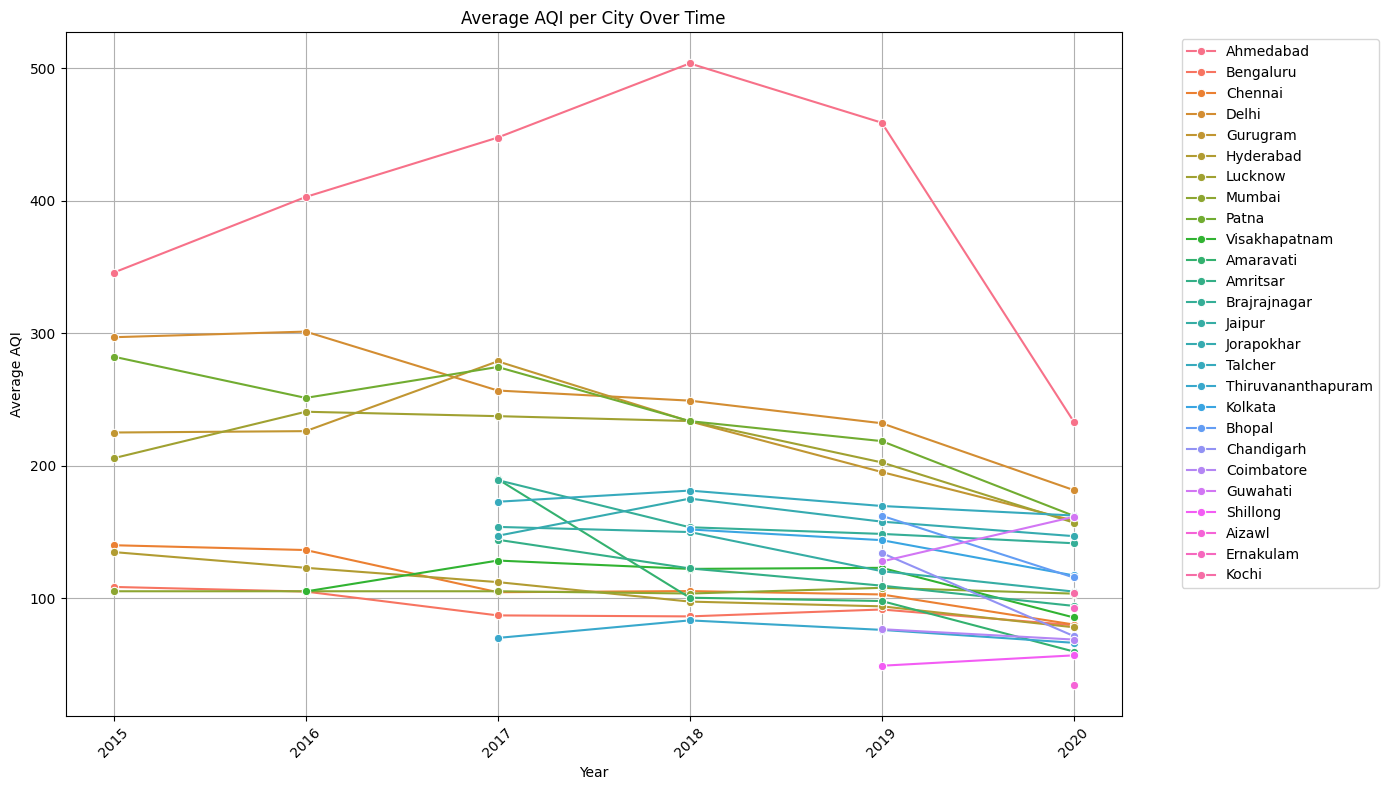

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the year from the 'Date' column
city_cleaned['Year'] = city_cleaned['Date'].dt.year

# Calculate the average AQI for each year and city
city_yearly_avg_aqi = city_cleaned.groupby(['Year', 'City'])['AQI'].mean().reset_index()

# Plot the line chart for each city
plt.figure(figsize=(14, 8)) # Make figure larger to accommodate multiple lines
sns.lineplot(x='Year', y='AQI', hue='City', data=city_yearly_avg_aqi, marker='o') # Add hue='City'
plt.title('Average AQI per City Over Time') # Change title
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.xticks(city_yearly_avg_aqi['Year'].unique(), rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

Scatter Plot (Alternate):

**Not grouped by year**

This plot is confusing to visualize especially for a layman. Although it shows the overlap of AQI levels across multiple cities. We can see that the AQI tends to rise during the end and start of a year

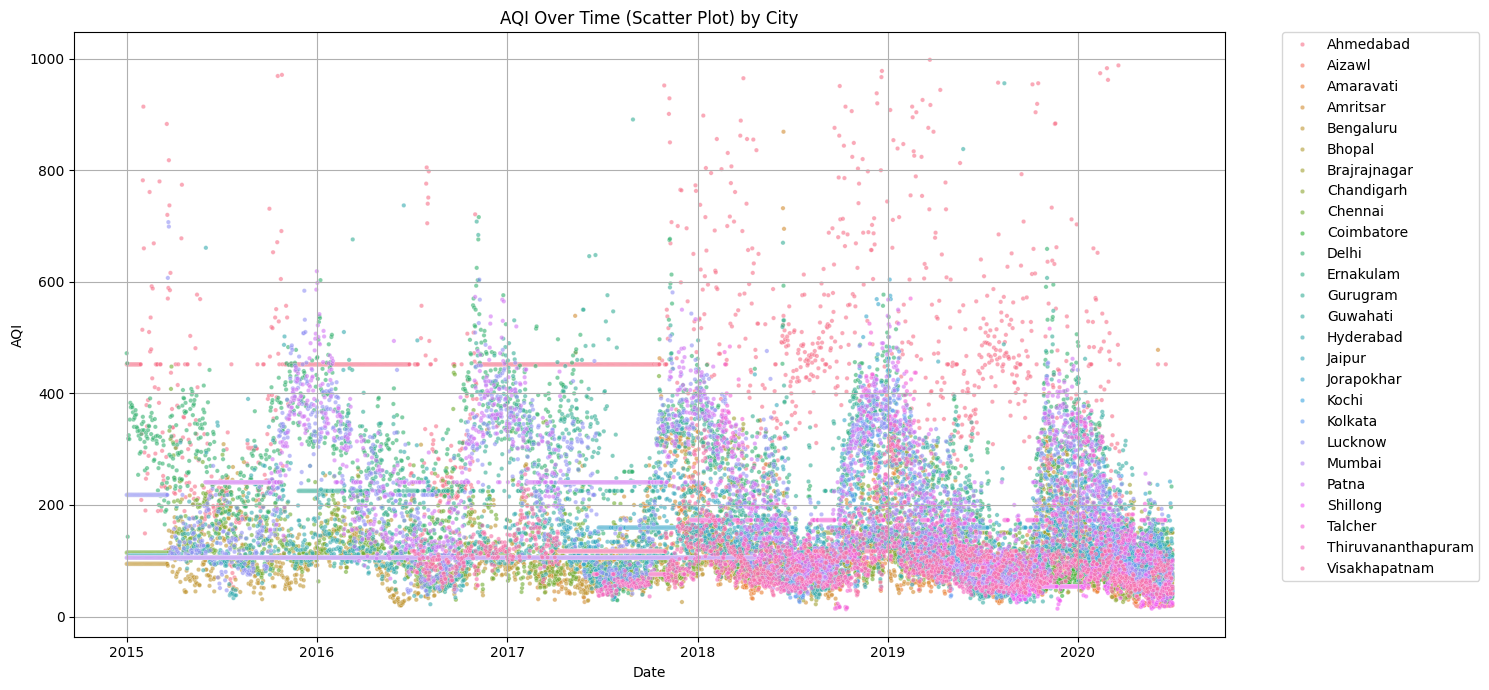

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.scatterplot(x='Date', y='AQI', hue='City', data=city_cleaned, alpha=0.6, s=10)
plt.title('AQI Over Time (Scatter Plot) by City') # Updated title
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Moved legend to avoid overlap
plt.tight_layout()
plt.show()

The easiest to notice data trend is the AQI level rapidly decreasing after 2020. This can be credited to the COVID-19 pandemic


# Task 7
**Analyzing trends between AQI and harvest seasons**

We've already noticed a slight trend of AQI levels increasing during the end and start of a year. To confirm the NGO's theory, we can try to group the time as months.

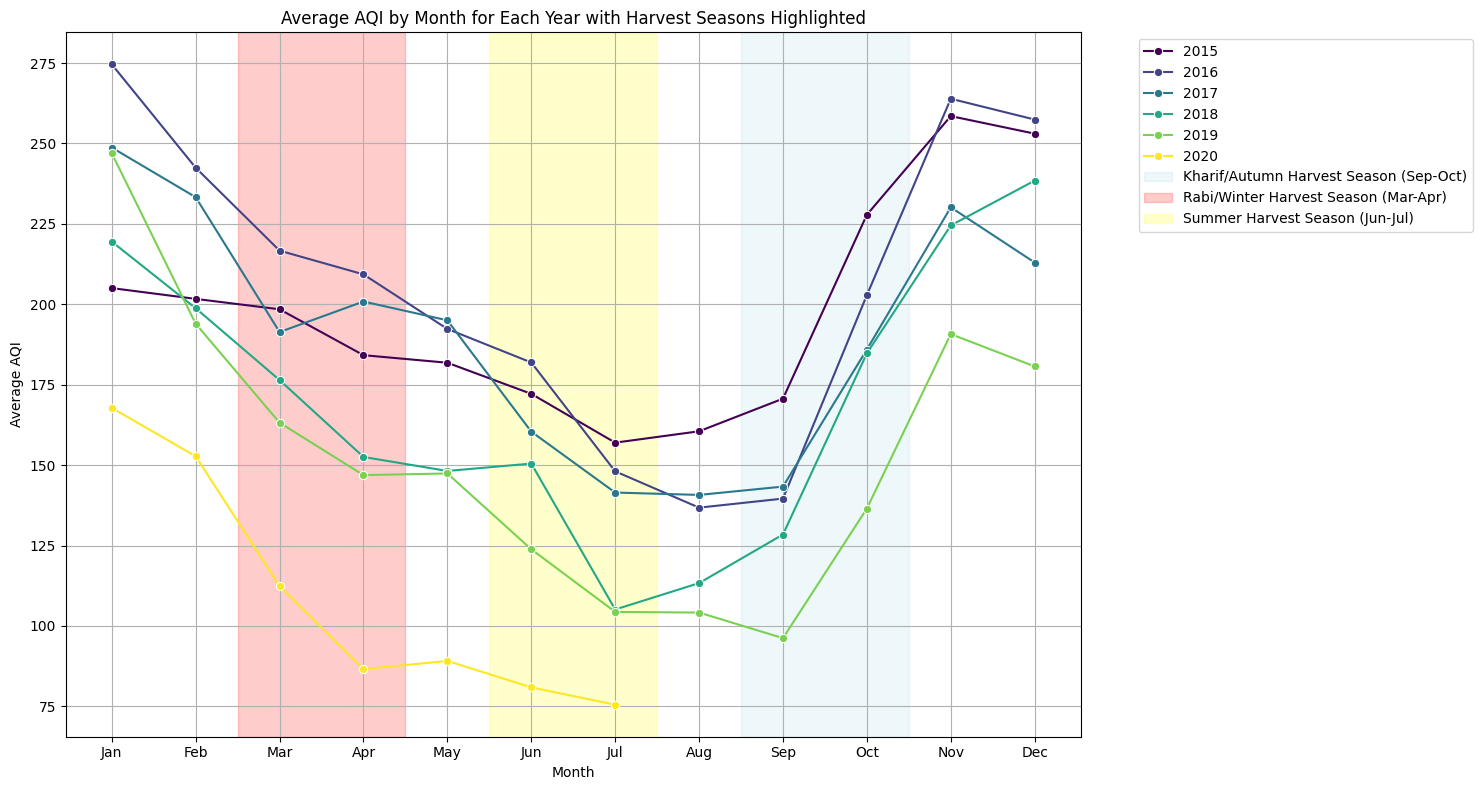

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Year' is extracted (already done in a previous cell, but good to ensure)
city_cleaned['Year'] = city_cleaned['Date'].dt.year
# Extract month from the 'Date' column
city_cleaned['Month'] = city_cleaned['Date'].dt.month

# Calculate the average AQI for each year and month
yearly_monthly_avg_aqi = city_cleaned.groupby(['Year', 'Month'])['AQI'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.lineplot(x='Month', y='AQI', hue='Year', data=yearly_monthly_avg_aqi, marker='o', palette='viridis')

# Highlight harvest seasons
# September to October (Month 9 to 10)
plt.axvspan(8.5, 10.5, color='lightblue', alpha=0.2, label='Kharif/Autumn Harvest Season (Sep-Oct)')
# March to April (Month 3 to 4)
plt.axvspan(2.5, 4.5, color='red', alpha=0.2, label='Rabi/Winter Harvest Season (Mar-Apr)')
# June to July (Month 6 to 7)
plt.axvspan(5.5, 7.5, color='yellow', alpha=0.2, label='Summer Harvest Season (Jun-Jul)')

plt.title('Average AQI by Month for Each Year with Harvest Seasons Highlighted')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
crop_cleaned['Season'].unique()

array(['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ',
       'Summer     ', 'Winter     '], dtype=object)

**Verdict on NGO's claim:**

We can see that the AQI levels repeatedly increase during the Autumn harvest season (September to October). So, the NGOs are correct about the theory that "air quality is worst exactly when they harvest."




# Task 8


Preparing data to perform merge


In [23]:
city_cleaned['Year'] = city_cleaned['Date'].dt.year

city_year = city_cleaned.groupby(
    ['City', 'Year']
).mean(numeric_only=True).reset_index()


In [24]:
city_state_map = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': None,  # No matching state in crop dataset
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

In [25]:
city_year['State_Name'] = city_year['City'].map(city_state_map)
city_year['State_Name'].isna().sum()

city_year[city_year['State_Name'].isna()]['City'].unique() #Delhi has no State to be mapped to

city_year = city_year.dropna(subset=['State_Name']) # remove Delhi



In [26]:
set(city_year['State_Name']) & set(crop_cleaned['State_Name']) #Verifying mapping

{'Andhra Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Gujarat',
 'Haryana',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Madhya Pradesh',
 'Maharashtra',
 'Meghalaya',
 'Mizoram',
 'Odisha',
 'Punjab',
 'Rajasthan',
 'Tamil Nadu',
 'Telangana',
 'Uttar Pradesh',
 'West Bengal'}

In [27]:
state_air = city_year.groupby(
    ['State_Name', 'Year']
).mean(numeric_only=True).reset_index()

In [40]:
state_crop = crop_cleaned.groupby(
    ['State_Name', 'Crop_Year']
).agg({
    'Area': 'sum',
    'Production': 'sum'
}).reset_index()

state_crop['Yield'] = (
    state_crop['Production'] /
    state_crop['Area']
)

print(state_crop.columns)

Index(['State_Name', 'Crop_Year', 'Area', 'Production', 'Yield'], dtype='object')


Merging on  State_Name as Year does not return any matches since there is a mismatch in the timeperiod of this data's recording.

The `crop` data has data recorded from 1997-2015 while `city` has data recorded from 2015-2020

We have also engineered another feature called **Yield** that is a more generalized measure of crop production that is tolerant to the area of the state.

In [41]:
merged = pd.merge(state_air, state_crop, on='State_Name', how='inner')
merged.head()

,State_Name,Year,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,Month,Crop_Year,Area,Production,Yield
0,Andhra Pradesh,2016,44.939442,88.518359,16.534364,42.238474,32.596386,13.298453,1.077937,21.303972,43.332568,6.164011,10.58601,105.20428,9.494565,1997,6660700.0,2.109350e+07,3.166859
1,Andhra Pradesh,2016,44.939442,88.518359,16.534364,42.238474,32.596386,13.298453,1.077937,21.303972,43.332568,6.164011,10.58601,105.20428,9.494565,1998,7192000.0,2.499760e+07,3.475751
2,Andhra Pradesh,2016,44.939442,88.518359,16.534364,42.238474,32.596386,13.298453,1.077937,21.303972,43.332568,6.164011,10.58601,105.20428,9.494565,1999,6545778.0,2.527677e+07,3.861537
3,Andhra Pradesh,2016,44.939442,88.518359,16.534364,42.238474,32.596386,13.298453,1.077937,21.303972,43.332568,6.164011,10.58601,105.20428,9.494565,2000,7587007.0,1.109120e+09,146.186810
4,Andhra Pradesh,2016,44.939442,88.518359,16.534364,42.238474,32.596386,13.298453,1.077937,21.303972,43.332568,6.164011,10.58601,105.20428,9.494565,2001,7197043.0,1.139997e+09,158.398009


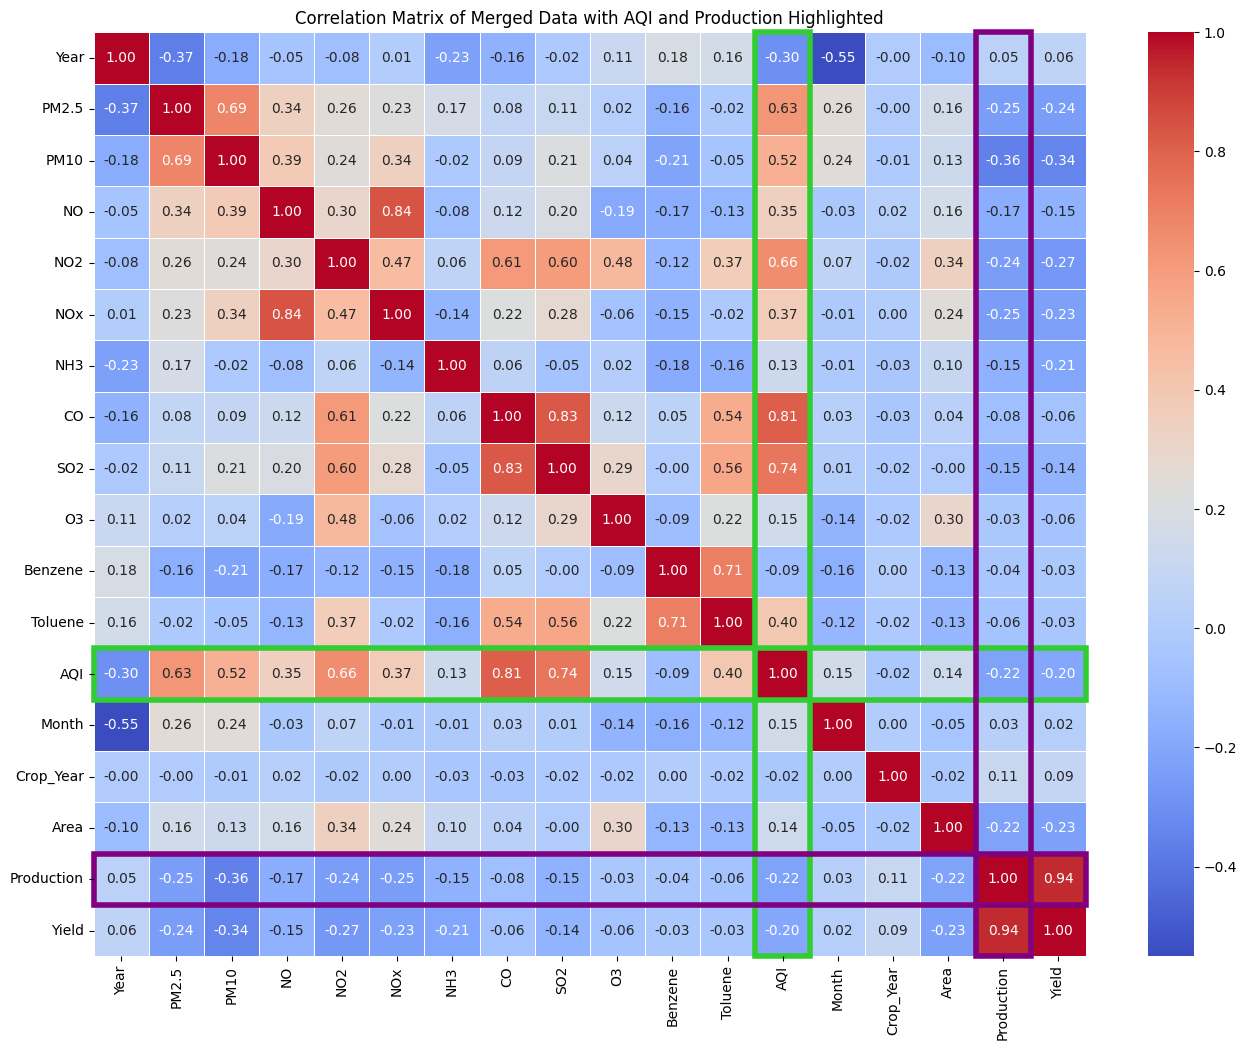

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the correlation matrix for numerical columns
correlation_matrix = merged.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(16, 12))
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Merged Data with AQI and Production Highlighted')

# Highlight 'AQI' and 'Production'
highlight_vars = {'AQI': 'limegreen', 'Production': 'purple'}

# Get the list of columns from the correlation matrix for proper indexing
columns = correlation_matrix.columns.tolist()

for var, color in highlight_vars.items():
    if var in columns:
        idx = columns.index(var)
        # Highlight the column
        ax.add_patch(plt.Rectangle((idx, 0), 1, len(columns), fill=False, edgecolor=color, lw=4, clip_on=False))
        # Highlight the row
        ax.add_patch(plt.Rectangle((0, idx), len(columns), 1, fill=False, edgecolor=color, lw=4, clip_on=False))

plt.show()

The matrix suggests a moderate negative relationship between air pollution and agricultural performance, with PM10 showing the strongest association. While the correlations are not strong enough to establish causation, they provide evidence that higher pollution levels may be linked to reduced crop productivity and warrant further investigation using regression or causal analysis techniques.

# Task 9

Our analysis suggests that poorer air quality may be linked to lower agricultural performance, although the evidence is not strong enough to prove a direct cause-and-effect relationship.

**Finding 1:**

States with higher levels of airborne particles (PM10) tended to have lower crop production and lower crop yield. This suggests that dust and pollution may affect plant growth and productivity.

**Finding 2:**

Areas with worse overall air quality generally showed lower agricultural performance. Farmers in more polluted regions may therefore face additional challenges beyond weather and soil conditions.

**Finding 3:**

Several pollutants, including particulate matter, nitrogen compounds, and sulfur compounds, tended to rise together. This indicates that pollution is often driven by common sources such as traffic, industry, and fuel combustion.

**What this means for farmers:**

Poor air quality may reduce crop productivity, potentially affecting farm income and food production.

**Recommendation:**

Strengthen air pollution control measures in agricultural regions, particularly targeting sources of particulate pollution such as industrial emissions, open burning, and vehicle exhaust.

**Limitation:**

The available datasets did not fully overlap in time, meaning the analysis can identify patterns but cannot prove that pollution directly causes lower crop production. Further data collection and targeted studies are needed before drawing firm conclusions.